# U.S. Treasury NSS Rich–Cheap Research

A learning project on curve fitting, residual signals and backtest fragility—not a production trading system.

**Research question:** Do unusually large deviations from a daily NSS fit identify subsequent favorable yield moves after approximate trading costs?

**Read this notebook in order:** data and curve diagnostics → training-only parameter selection → frozen-rule historical test → extreme-day audit → quote-calendar and execution sensitivity.

The cells import one maintained implementation from `src/`. The English text and repository organization were updated without retuning the strategy. This notebook was executed from the versioned raw snapshot. See `reports/provenance.json` for the source hash and `reports/validation.json` for reproduction checks against the supplied notebook.

All quoted performance uses approximate bucket price returns. The historical test has been inspected repeatedly; subsequent diagnostics are exploratory, not a new untouched holdout.

## 1. Environment and research implementation
Run from the repository root or the `notebooks/` directory. Importing the module does not download data or run a backtest. The default workflow uses the versioned raw FRED snapshot if available, or otherwise requests the configured dates from FRED.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if not (ROOT / "src" / "treasury_rich_cheap_nss.py").exists():
    raise RuntimeError("Open this notebook from the repository root or notebooks/ directory.")
sys.path.insert(0, str(ROOT / "src"))
import treasury_rich_cheap_nss as research
from research_io import use_snapshot, export_results, plot_calendar_comparison

snapshot = ROOT / "data" / "fred_yields_raw.csv"
if snapshot.exists():
    use_snapshot(research, snapshot)
    print("Using versioned raw FRED snapshot:", snapshot.name)
else:
    print("No snapshot found; using live FRED requests. Historical values may differ.")

Using versioned raw FRED snapshot: fred_yields_raw.csv


## 2. Data, daily NSS calibration and descriptive diagnostics

Ten Treasury constant-maturity yield series span 3M–30Y. The legacy baseline forward-fills missing rows; this is intentionally preserved as variant A, then challenged in section 5.

The NSS curve is fitted separately each day to yields in decimal units. Its six fitted parameters are distinct from the trading hyperparameters selected later. Residuals equal observed minus fitted yield.

KMO and PCA describe the full-sample yield-change structure; they are not trading inputs and do not establish predictive validity. The last-date fitted curve is an illustration, not evidence that residuals are executable mispricing.

Fetching FRED Treasury yield data...
Actual data range: 2010-01-04 to 2026-08-31

KMO Test Results:
Overall KMO: 0.8918
Interpretation: great

KMO by Maturity:
3M     0.7858
6M     0.8231
1Y     0.8991
2Y     0.9152
3Y     0.9171
5Y     0.9094
7Y     0.8973
10Y    0.9253
20Y    0.8663
30Y    0.8607
Name: KMO, dtype: float64


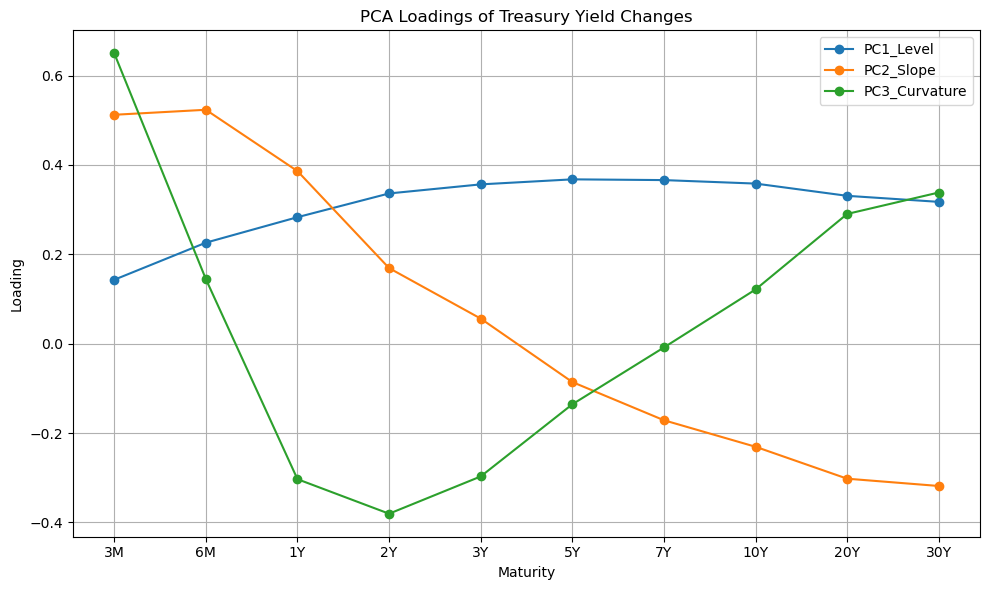


PCA Explained Variance:
PC1_Level        0.686815
PC2_Slope        0.171680
PC3_Curvature    0.075745
dtype: float64
Calibrating NSS curve day by day...


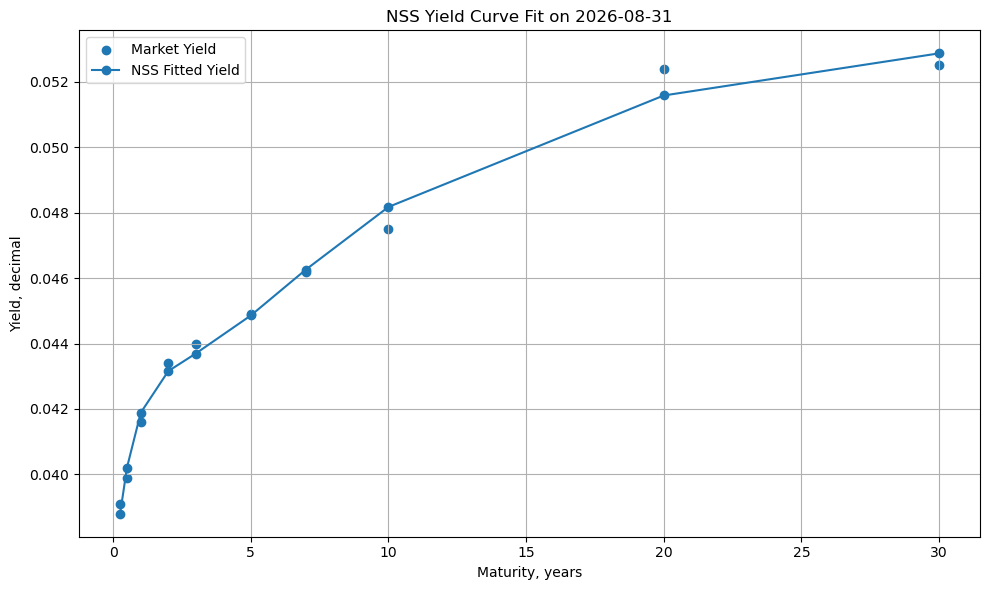

In [2]:
output = research.main()

## 3. Training-only selection and frozen-rule evaluation

Only 2010–2017 observations are used to rank nine `(window, entry_z)` pairs. A common warm-up keeps candidate scoring dates aligned. The selected residual window is 252 observations and the entry threshold is 2.0 in the supplied run.

On each signal date, select up to two cheap and two rich buckets beyond the thresholds. Inverse-duration weights are normalized within each side; both sides receive half the gross budget, while a sole active side receives the full budget. This is **not DV01 neutral**. Targets are rebuilt daily; there is no separate exit threshold in this baseline.

Returns use the preceding target. The orange segment is the selected rule viewed in-sample; blue is the historical test from 2018 onward. Benchmarks are gross price-return proxies, not investable total-return indices or risk-matched controls.

Common training scoring start: 2011-06-16 (earlier observations are warm-up only)

Training parameter comparison:
 window  entry_z  Sharpe    CAGR  Ann Vol  Max Drawdown
    252      2.0  0.7359  0.0177   0.0234       -0.0386
    378      1.5  0.6296  0.0178   0.0276       -0.0320
    252      1.5  0.5005  0.0146   0.0289       -0.0567
    378      2.5  0.4897  0.0051   0.0101       -0.0162
    126      2.5  0.3513  0.0073   0.0206       -0.0372
    378      2.0  0.1528  0.0034   0.0233       -0.0448
    252      2.5  0.1163  0.0015   0.0135       -0.0345
    126      2.0 -0.2848 -0.0087   0.0282       -0.1355
    126      1.5 -0.6056 -0.0188   0.0295       -0.1416

Frozen parameters:
window = 252, entry_z = 2.0



Period performance:
           Period      Start        End  Obs  Total Return   CAGR  Ann Vol  Sharpe  Max Drawdown
Train (selection) 2011-06-16 2017-12-29 1707        0.1217 0.0177   0.0234  0.7359       -0.0386
   Test 2018–2026 2018-01-01 2026-08-31 2261        0.1742 0.0187   0.0294  0.6235       -0.0427
   Test 2018–2021 2018-01-01 2021-12-31 1045        0.1035 0.0249   0.0310  0.7812       -0.0427
   Test 2022–2026 2022-01-03 2026-08-31 1216        0.0641 0.0134   0.0280  0.4747       -0.0384
Test subperiods decompose the same frozen strategy; parameters are not reselected.

Test returns by calendar year:
 Year      Start        End  Obs  Period Return
 2018 2018-01-01 2018-12-31  261         0.0225
 2019 2019-01-01 2019-12-31  261         0.0122
 2020 2020-01-01 2020-12-31  262         0.0412
 2021 2021-01-01 2021-12-31  261         0.0240
 2022 2022-01-03 2022-12-30  260         0.0013
 2023 2023-01-02 2023-12-29  260         0.0336
 2024 2024-01-01 2024-12-31  262        -0.

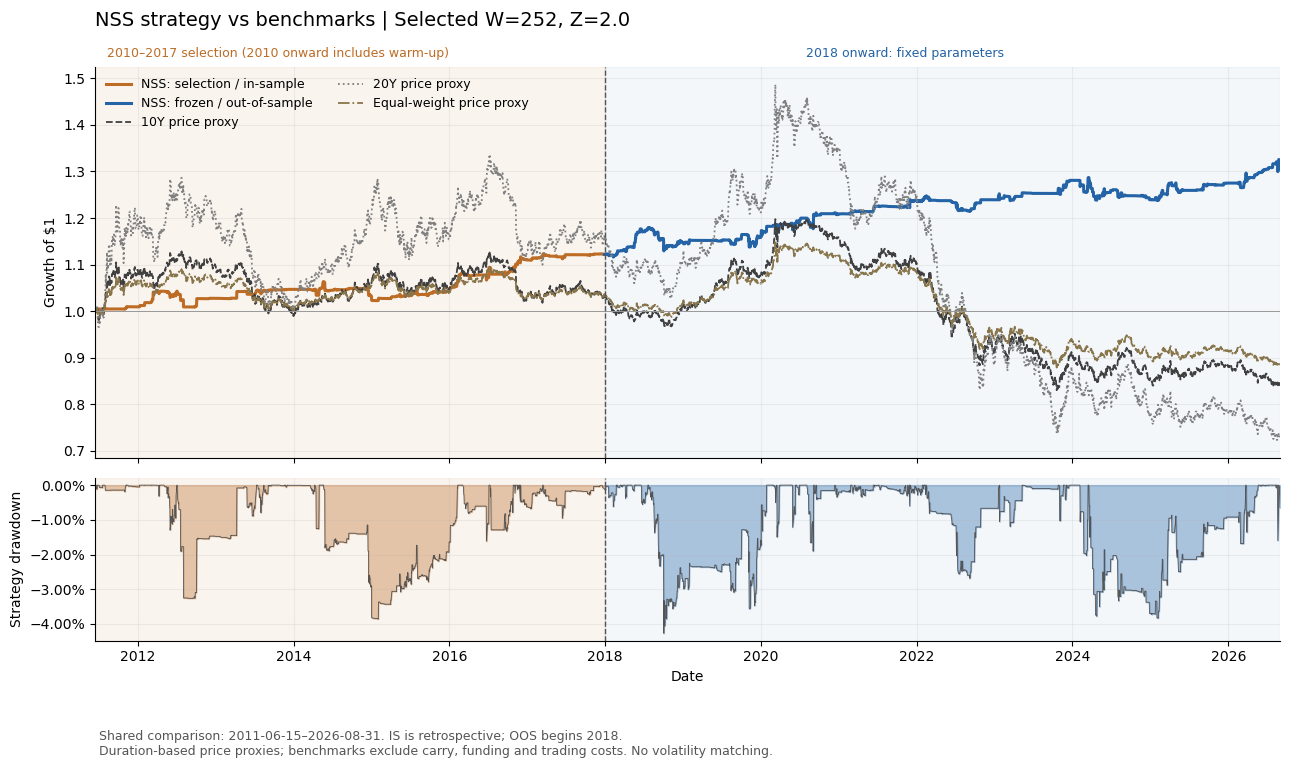

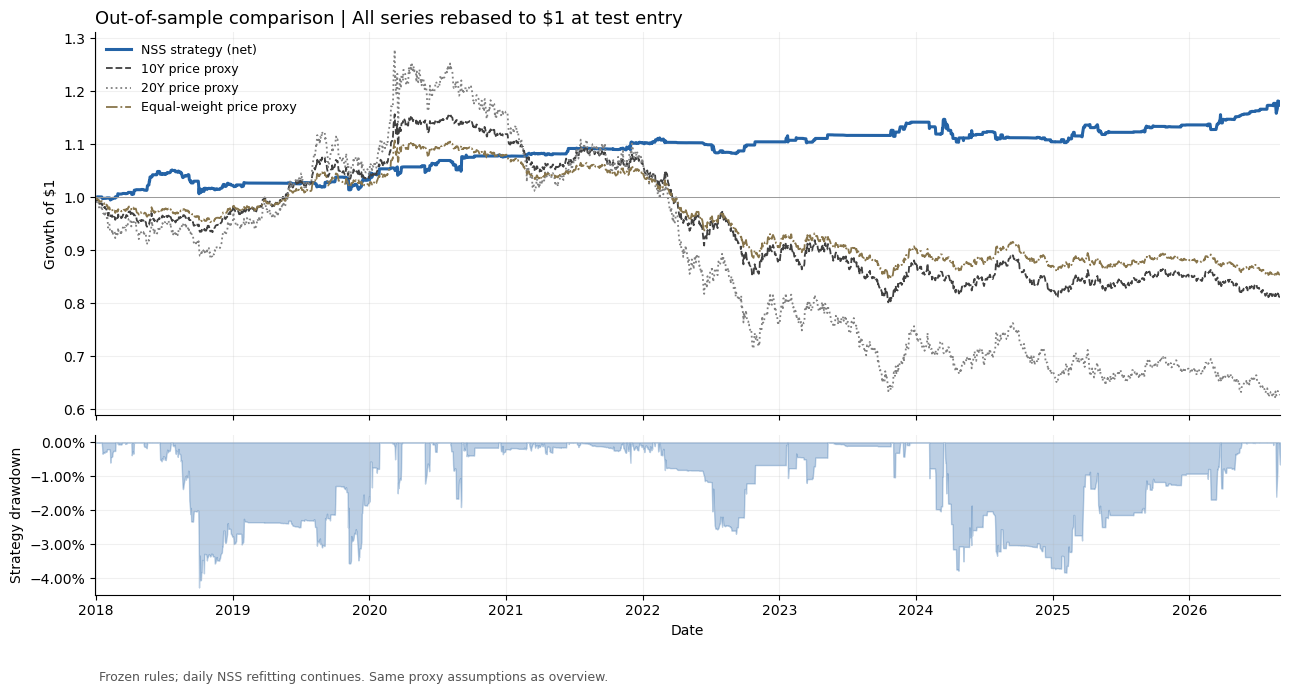

In [3]:
oos_output = research.run_oos_test(output)

## 4. Where do large PnL days come from? Legacy timing audit

Reconstruct daily gross PnL from lagged weights, yield changes, duration and convexity. Inspect both best and worst dates, then shift **all** target changes by one additional observation, including exits.

This is a legacy-calendar diagnostic. Its delay conclusion must not be generalized to the quote-date calendar below. Best/worst dates are selected retrospectively for explanation, not used as a trading filter. `Position Signal Date` is the target-formation date, not necessarily the original entry date.


===== Train: Best 10 days =====


,Period,Group,PnL Date,Position Signal Date,Calendar Gap,Regime,Holdings,Gross Return (%),Cost (%),Net Return (%),Signed Duration
0,Train,Best,2016-07-05,2016-07-04,1,Long only,30Y: +100.0%,2.00023,0.00577,1.99446,20.00000
1,Train,Best,2013-04-10,2013-04-09,1,Short only,30Y: -100.0%,1.39989,0.00571,1.39418,-20.00000
2,Train,Best,2012-10-04,2012-10-03,1,Short only,30Y: -100.0%,1.39989,0.00590,1.39399,-20.00000
3,Train,Best,2012-03-14,2012-03-13,1,Short only,7Y: -100.0%,1.05393,0.00584,1.04810,-6.20000
4,Train,Best,2014-05-19,2014-05-16,3,Short only,30Y: -100.0%,0.99994,0.00566,0.99428,-20.00000
5,Train,Best,2014-05-01,2014-04-30,1,Long only,20Y: +100.0%,0.90004,0.00571,0.89433,15.00000
6,Train,Best,2016-02-08,2016-02-05,3,Long only,10Y: +100.0%,0.88005,0.00546,0.87458,8.00000
7,Train,Best,2016-11-07,2016-11-04,3,Short only,30Y: -100.0%,0.79996,0.00564,0.79432,-20.00000
8,Train,Best,2016-02-17,2016-02-16,1,Short only,20Y: -100.0%,0.74997,0.00606,0.74391,-15.00000
9,Train,Best,2012-06-29,2012-06-28,1,Short only,"7Y: -76.3%, 30Y: -23.7%",0.66255,0.00554,0.65700,-9.46565


Maturity-level holdings and PnL details:


,Period,Group,PnL Date,Position Signal Date,Maturity,Held Weight,Z at Signal Date,Previous Yield (%),Current Yield (%),Yield Change (bp),Duration,Linear Contribution (pp),Convexity Contribution (pp),Gross Contribution (pp)
0,Train,Best,2016-07-05,2016-07-04,30Y,1.000000,2.049139,2.24,2.14,-10.0,20.0,2.000000,0.000225,2.000225
1,Train,Best,2013-04-10,2013-04-09,30Y,-1.000000,-2.392093,2.94,3.01,7.0,20.0,1.400000,-0.000110,1.399890
2,Train,Best,2012-10-04,2012-10-03,30Y,-1.000000,-2.103154,2.82,2.89,7.0,20.0,1.400000,-0.000110,1.399890
3,Train,Best,2012-03-14,2012-03-13,7Y,-1.000000,-2.174209,1.52,1.69,17.0,6.2,1.054000,-0.000065,1.053935
4,Train,Best,2014-05-19,2014-05-16,30Y,-1.000000,-2.042723,3.34,3.39,5.0,20.0,1.000000,-0.000056,0.999944
5,Train,Best,2014-05-01,2014-04-30,20Y,1.000000,2.053057,3.22,3.16,-6.0,15.0,0.900000,0.000045,0.900045
6,Train,Best,2016-02-08,2016-02-05,10Y,1.000000,2.291176,1.86,1.75,-11.0,8.0,0.880000,0.000045,0.880045
7,Train,Best,2016-11-07,2016-11-04,30Y,-1.000000,-2.138378,2.56,2.60,4.0,20.0,0.800000,-0.000036,0.799964
8,Train,Best,2016-02-17,2016-02-16,20Y,-1.000000,-2.013531,2.19,2.24,5.0,15.0,0.750000,-0.000031,0.749969
9,Train,Best,2012-06-29,2012-06-28,7Y,-0.763359,-2.123368,1.06,1.11,5.0,6.2,0.236641,-0.000004,0.236637



===== Train: Worst 10 days =====


...

,Period,Group,PnL Date,Position Signal Date,Maturity,Held Weight,Z at Signal Date,Previous Yield (%),Current Yield (%),Yield Change (bp),Duration,Linear Contribution (pp),Convexity Contribution (pp),Gross Contribution (pp)
31,Test,Worst,2019-11-07,2019-11-06,20Y,1.0,2.665509,2.13,2.24,11.0,15.0,-1.650,0.000151,-1.649849
32,Test,Worst,2018-10-03,2018-10-02,20Y,1.0,2.098388,3.14,3.24,10.0,15.0,-1.500,0.000125,-1.499875
33,Test,Worst,2020-03-17,2020-03-16,7Y,1.0,4.827799,0.67,0.91,24.0,6.2,-1.488,0.000130,-1.487870
34,Test,Worst,2020-05-29,2020-05-28,30Y,-1.0,-2.579810,1.47,1.41,-6.0,20.0,-1.200,-0.000081,-1.200081
35,Test,Worst,2024-02-23,2024-02-22,20Y,-1.0,-2.392167,4.58,4.51,-7.0,15.0,-1.050,-0.000061,-1.050061
36,Test,Worst,2024-02-06,2024-02-05,20Y,-1.0,-2.037757,4.46,4.39,-7.0,15.0,-1.050,-0.000061,-1.050061
37,Test,Worst,2023-01-24,2023-01-23,20Y,-1.0,-2.232687,3.80,3.73,-7.0,15.0,-1.050,-0.000061,-1.050061
38,Test,Worst,2019-11-05,2019-11-04,20Y,1.0,2.833823,2.10,2.17,7.0,15.0,-1.050,0.000061,-1.049939
39,Test,Worst,2023-11-02,2023-11-01,10Y,0.5,2.205435,4.77,4.67,-10.0,8.0,0.400,0.000019,0.400019
40,Test,Worst,2023-11-02,2023-11-01,30Y,-0.5,-2.053063,4.96,4.82,-14.0,20.0,-1.400,-0.000220,-1.400220



===== Execution-delay sensitivity =====


,Period,Variant,Start,End,Net Total Return (%),Net CAGR (%),Gross Ann Mean (%),Cost Ann (%),Net Ann Mean (%),Ann Vol (%),Sharpe (vs zero),Max Drawdown (%)
0,Train,Original,2011-06-16,2017-12-29,12.1665,1.7709,2.2102,0.4878,1.7224,2.3405,0.7359,-3.8633
1,Train,Extra 1-observation delay,2011-06-16,2017-12-29,9.1334,1.3452,1.8081,0.4887,1.3194,2.4200,0.5452,-4.1544
2,Test,Original,2018-01-01,2026-08-31,17.4231,1.8696,2.4337,0.6004,1.8334,2.9405,0.6235,-4.2721
3,Test,Extra 1-observation delay,2018-01-01,2026-08-31,4.8292,0.5454,1.1774,0.5999,0.5774,3.2188,0.1794,-9.5705



===== Original extreme dates: same-date comparison =====


,Period,Group,PnL Date,Regime,Original Net (%),Delayed Net (%),Difference (pp)
0,Train,Best,2016-07-05,Long only,1.9945,2.0002,0.0058
1,Train,Best,2013-04-10,Short only,1.3942,-0.0057,-1.3999
2,Train,Best,2012-10-04,Short only,1.3940,1.3999,0.0059
3,Train,Best,2012-03-14,Short only,1.0481,1.0539,0.0058
4,Train,Best,2014-05-19,Short only,0.9943,0.0506,-0.9437
5,Train,Best,2014-05-01,Long only,0.8943,0.9000,0.0057
6,Train,Best,2016-02-08,Long only,0.8746,-0.0055,-0.8800
7,Train,Best,2016-11-07,Short only,0.7943,0.3217,-0.4726
8,Train,Best,2016-02-17,Short only,0.7439,0.7500,0.0061
9,Train,Best,2012-06-29,Short only,0.6570,0.3074,-0.3496


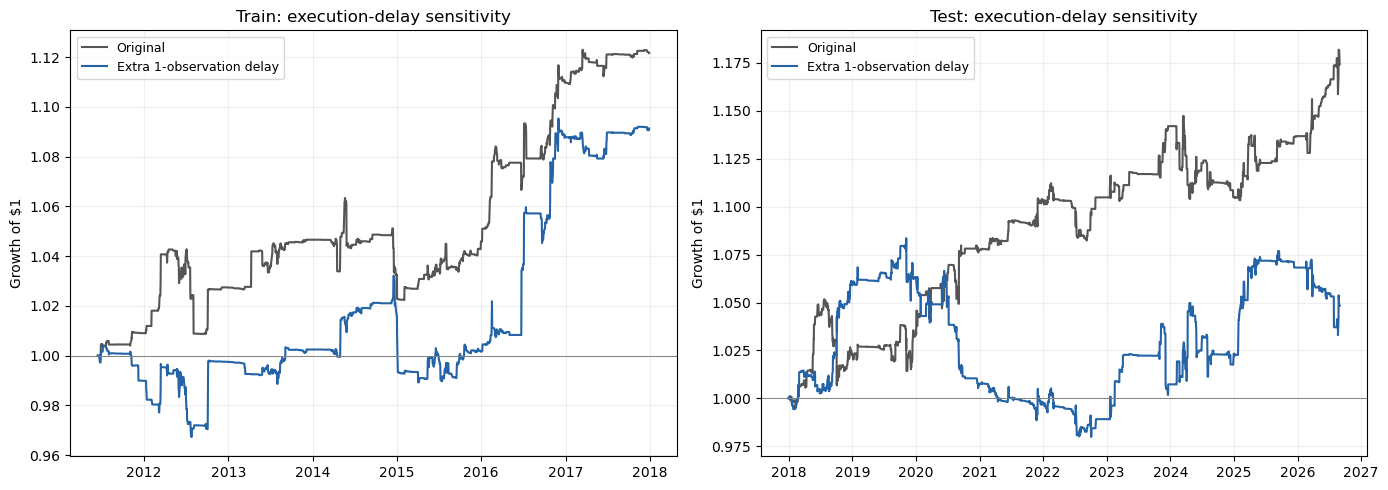

In [4]:
timing_audit = research.audit_extreme_days_and_delay(output, oos_output)

## 5. Valid quote dates and execution assumptions

Read original missingness, verify that the snapshot reproduces the baseline, stop on partial missingness, and remove only rows missing all maturities. Unchanged but valid quotes are retained. Refit NSS and recompute rolling statistics on this calendar.

- **A:** legacy forward-filled dates and original timing.
- **B:** valid quote dates and original timing.
- **C:** valid quote dates with all targets delayed by one additional quote observation.

Parameters remain frozen from the legacy training selection; B/C are not independently optimized. This section uses actual observations per year for volatility and Sharpe, and a later common training warm-up. Its Sharpe values therefore differ from section 3.

Calendar cleaning changes rolling windows, optimization warm starts, positions and costs—not just the seven no-quote rebalances. Daily FRED data do not verify the publication-to-execution timeline or executable prices.

In [5]:
calendar_audit = research.audit_quote_dates_and_execution(output, oos_output)

===== Raw-data missingness audit =====


,Count
Rows on the original date index,4346
Rows missing all maturities,178
Rows missing some maturities,0
Rows complete across all maturities,4168



===== Baseline rebalancing on dates without quotes =====
No-quote rows with target position changes: 7


,Target turnover,Target gross exposure,Recorded cost (%)
DATE,,,
2020-07-03,1.632653,1.0,0.009125
2012-07-04,1.000000,1.0,0.005552
2010-11-25,1.000000,1.0,0.005847
2015-11-11,1.000000,0.0,0.005564
2013-05-27,1.000000,1.0,0.005250
2019-11-28,1.000000,1.0,0.005637
2018-10-08,0.183673,1.0,0.000944
2019-02-18,0.000000,0.0,0.000000
2019-04-19,0.000000,0.0,0.000000



===== Refitting NSS on valid quote dates =====
Calibrating NSS curve day by day...


Rows with missing NSS fits: 0



Fixed parameters:window=252, entry_z=2.0, top_n=2, gross_leverage=1.0
Common training scoring start: 2011-07-06
Volatility and Sharpe below use observed annual frequency and may differ from legacy tables.

===== Calendar and execution assumption comparison =====


,Period,Variant,Start,End,Obs,Obs/year,Net total (%),Net CAGR (%),Gross ann mean (%),Cost ann (%),Ann vol (%),Sharpe vs zero,Max drawdown (%)
0,Train,A Original,2011-07-06,2017-12-29,1693,261.0250,11.6579,1.7147,2.2298,0.5011,2.3875,0.7240,-3.8633
1,Train,B Quote dates,2011-07-06,2017-12-29,1624,250.3867,15.7910,2.2863,2.7465,0.4623,2.1713,1.0520,-3.3118
2,Train,C Quote dates + delay,2011-07-06,2017-12-29,1624,250.3867,0.4813,0.0741,0.5591,0.4633,2.0880,0.0459,-4.5532
3,Test,A Original,2018-01-01,2026-08-31,2261,260.7611,17.4231,1.8696,2.5184,0.6213,2.9911,0.6342,-4.2721
4,Test,B Quote dates,2018-01-02,2026-08-31,2166,249.8047,10.8388,1.1939,1.8411,0.6084,3.0290,0.4070,-5.4047
5,Test,C Quote dates + delay,2018-01-02,2026-08-31,2166,249.8047,14.7620,1.6007,2.2541,0.6080,3.4142,0.4821,-6.2354



===== Timing example: around 2016-07-04 =====


,Return interval start,Return interval end,B target signal date,C target signal date,Calendar gap
DATE,,,,,
2016-06-30,2016-06-29,2016-06-30,2016-06-29,2016-06-28,1.0
2016-07-01,2016-06-30,2016-07-01,2016-06-30,2016-06-29,1.0
2016-07-05,2016-07-01,2016-07-05,2016-07-01,2016-06-30,4.0
2016-07-06,2016-07-05,2016-07-06,2016-07-05,2016-07-01,1.0
2016-07-07,2016-07-06,2016-07-07,2016-07-06,2016-07-05,1.0
2016-07-08,2016-07-07,2016-07-08,2016-07-07,2016-07-06,1.0


## 6. Export inspectable evidence

Exports tables, daily return series, holdings and a calendar-sensitivity chart. The `reports/` directory contains regenerated figures, full-precision tables, and display-precision source evidence for comparison.

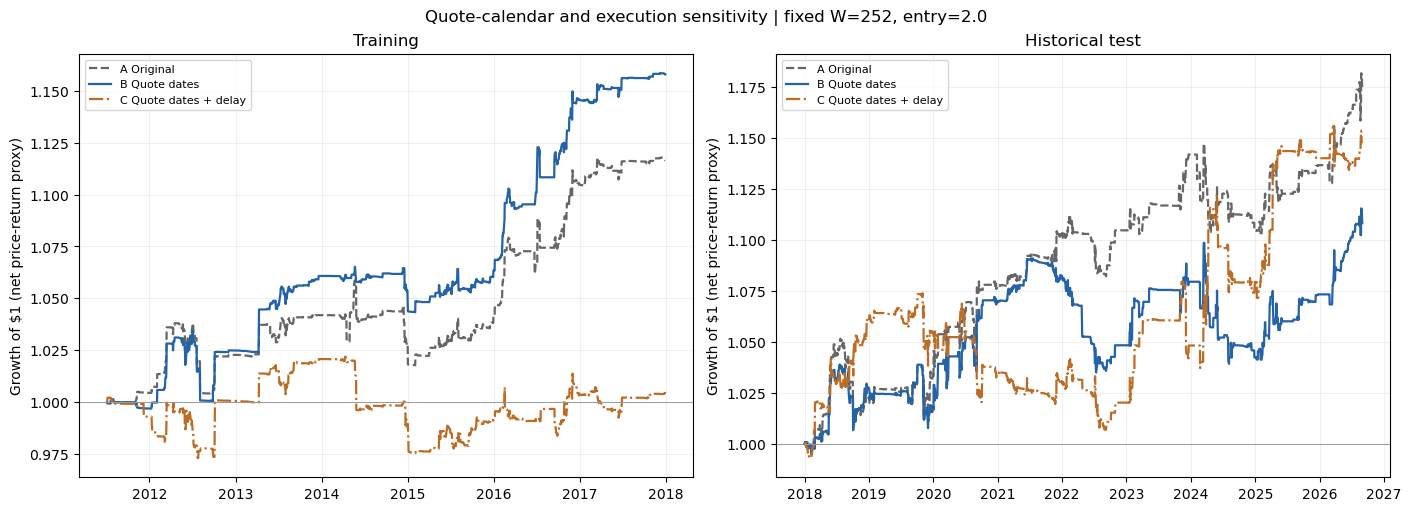

In [6]:
export_results(ROOT, output, oos_output, timing_audit, calendar_audit)
_ = plot_calendar_comparison(calendar_audit, ROOT / "reports" / "figures" / "quote_calendar_comparison.png")

## 7. Findings, limitations and next question

The supplied legacy test reports 1.87% CAGR and 0.62 Sharpe versus zero. Quote-date cleaning reduces test CAGR to 1.19%; adding a quote-observation delay increases it to 1.60% but worsens maximum drawdown. The delayed quote-date variant nearly loses its training-period net return. There is no stable ranking of timing variants across samples.

Large daily gains and losses are frequently single-sided long-duration exposures. Positive returns do not isolate relative-value alpha from directional rate risk. Cost, duration and convexity values are illustrative; carry, financing, instrument-level pricing and actual futures rolls are absent.

**Next research question, not implemented:** How sensitive are same-date NSS residuals and threshold crossings to optimization initialization and removal of stale rows? Do not select a new timing rule by choosing the best test result.